# 01. 탐색적 데이터 분석 (EDA)

## 분석 질문
보험 상품 선택을 결정하는 요인은 연령인가, 직업인가?

## 데이터
AI Hub「금융상품·서비스 및 소비자 특성 데이터」
- 사용 파일: Training/02.라벨링데이터/TL_2.소비자.zip → 소비자.csv
- Validation은 Training과 동일 내용이므로 미사용

## 한계
특정 보험사 계약 데이터로 국내 보험시장 전체를 대표하지 않음

In [1]:
import zipfile, json, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rc("font", family="Malgun Gothic")
mpl.rc("axes", unicode_minus=False)
sns.set_theme(style="whitegrid", font="Malgun Gothic")
pd.set_option("display.max_columns", 50)

ROOT = pathlib.Path.cwd().parent          # notebooks/ 기준 상위
FIG  = ROOT / "figures"; FIG.mkdir(exist_ok=True)

LBL = next(ROOT.rglob("02.라벨링데이터"))
print(LBL.exists())

True


## 1. 데이터 로드

In [3]:
with zipfile.ZipFile(LBL / "TL_2.소비자.zip") as zf:
    with zf.open("소비자.csv") as f:
        con = pd.read_csv(f, encoding="utf-8")

print("전체:", con.shape)
con.head(10)

전체: (385019, 22)


,customer_id,customer_seq,customer_type,age,gender,region,income_bracket,occupation_group,risk_grade,credit_rating,marital_status,investment_propensity,cross_coverage,disease_history,product_name,product_amt,product_period,transaction_type,transaction_keyword,transaction_amt,transaction_start_year,transaction_last_year
0,70366f8a547028962bb5e476979d6f4fe9cc3bf14a2491...,1,보험,20대,남,경기도,3000만원미만,비경제활동인구,A,700점대,기혼,-,기타only,없음,연금저축 SAVE연금보험1104,400000,2044,정상,종속 특약,100000,2024,2025
1,eb20df62d84a34645098febb4a9124ccda73408ae2c084...,1,보험,20대,남,경기도,3000만원미만,비경제활동인구,A,300점대,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,1000000,2044,정상,종속 특약,100000,2024,2025
2,fac63ec523f4d21b1992d516f7d02be0db3d013456f0be...,1,보험,20대,남,경기도,3000만원미만,비경제활동인구,A,800점대,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,10000000,2045,정상,독립특약,100000,2025,2025
3,f2453b0ddb1be306c75c12505c4853d13c5d18e06d4c4e...,1,보험,20대,남,경기도,3000만원미만,사무종사자,A,900점대이상,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,36000000,2035,정상,종속 특약,100000,2024,2025
4,ff681c97a92bc1eda94031e8c4f5a37853a1f31f60ba0d...,1,보험,20대,남,경기도,5000만원미만,비경제활동인구,A,800점대,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,10000000,2044,정상,종속 특약,100000,2024,2025
5,1957702a103468972a05aefab1cf773331bfc6e94d1d8d...,1,보험,20대,남,경상도,3000만원미만,비경제활동인구,A,800점대,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,10000000,2034,정상,종속 특약,100000,2024,2025
6,9476918d8f6210798c0ec61b325e6944cd8a428a009fbe...,1,보험,20대,남,경상도,3000만원미만,서비스 종사자,B,800점대,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,3000000,2071,정상,종속 특약,100000,2024,2025
7,337e450f5bfc81d7f3e95a3dcf2afdfb91375d690c09dd...,1,보험,20대,남,인천,5000만원미만,서비스 종사자,B,800점대,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,200000,2045,정상,독립특약,100000,2025,2025
8,6321dd872b2decb3fa3e42875a6c3d6932379d05bb8258...,1,보험,20대,남,전라도,5000만원미만,판매종사자,B,800점대,미혼,-,기타only,없음,연금저축 SAVE연금보험1104,200000,2044,정상,종속 특약,100000,2011,2025
9,8a71b29c831c17a92a7b39cf59440576f1eeb7defeaeda...,1,보험,20대,남,경기도,3000만원미만,전문가 및 관련 종사자,A,900점대이상,미혼,-,변액only,근골격계+척추계,미래에셋생명 변액연금보험 무배당 최저연금미보증형,12000000,9999,정상,주보험,100000,2024,2025


## 2. 원본 데이터 점검

전처리 이전 상태를 기록한다.

In [4]:
print("[컬럼]"); print(list(con.columns))
print("\n[결측률]"); print(con.isna().mean().round(4))
print("\n[고유값 수]"); print(con.nunique())
print("\n[customer_type]"); print(con["customer_type"].value_counts())
print("\n[age 원본]"); print(con["age"].value_counts())

[컬럼]
['customer_id', 'customer_seq', 'customer_type', 'age', 'gender', 'region', 'income_bracket', 'occupation_group', 'risk_grade', 'credit_rating', 'marital_status', 'investment_propensity', 'cross_coverage', 'disease_history', 'product_name', 'product_amt', 'product_period', 'transaction_type', 'transaction_keyword', 'transaction_amt', 'transaction_start_year', 'transaction_last_year']

[결측률]
customer_id               0.0
customer_seq              0.0
customer_type             0.0
age                       0.0
gender                    0.0
region                    0.0
income_bracket            0.0
occupation_group          0.0
risk_grade                0.0
credit_rating             0.0
marital_status            0.0
investment_propensity     0.0
cross_coverage            0.0
disease_history           0.0
product_name              0.0
product_amt               0.0
product_period            0.0
transaction_type          0.0
transaction_keyword       0.0
transaction_amt           0.0
t

## 3. 전처리

원본에서 발견한 문제와 처리 방식:

1. **분석 대상 한정** — `customer_type`에 증권·보험이 혼재. 보험 계약만 추출
2. **연령 라벨 중복** — `70대`와 `70대 이상`이 별도 값으로 존재. 동일 집단의 표기 오류로 판단하여 통합
3. **상품 카테고리 부재** — 개별 상품명만 존재하고 대분류 컬럼이 없어, 상품명 키워드 기반으로 6개 카테고리 생성

In [6]:
ins = con[con["customer_type"] == "보험"].copy()
ins["age"] = ins["age"].replace({"70대 이상": "70대"})
ins["start"] = pd.to_numeric(ins["transaction_start_year"], errors="coerce")

name = ins["product_name"].fillna("")
ins["cat"] = np.select(
    [name.str.contains("연금|저축|IRP"),
     name.str.contains("종신"),
     name.str.contains("암"),
     name.str.contains("건강|케어|질병|실손"),
     name.str.contains("정기")],
    ["연금·저축", "종신", "암", "건강·질병", "정기"],
    default="기타")

ins["is_variable"] = name.str.contains("변액")
AGE_ORDER = ["20대","30대","40대","50대","60대","70대"]

print(f"보험 계약 {len(ins):,}건 / 고객 {ins['customer_id'].nunique():,}명")
print(ins["age"].value_counts().reindex(AGE_ORDER))

보험 계약 77,305건 / 고객 74,776명
age
20대     7144
30대    11759
40대    15553
50대    21216
60대    16136
70대     5497
Name: count, dtype: int64


### 3-1. 카테고리 분류 검증

키워드 분류가 의도대로 작동했는지 카테고리별 대표 상품으로 확인한다.

In [7]:
for c in ins["cat"].value_counts().index:
    print(f"\n[{c}] {(ins['cat']==c).sum():,}건")
    print(ins[ins["cat"]==c]["product_name"].value_counts().head(3).to_string())


[건강·질병] 55,999건
product_name
M-케어 건강보험(갱신형) 무배당             25929
M-케어 건강보험(간편고지형(5),갱신형) 무배당    11344
M-케어 건강보험 무배당                  10889

[연금·저축] 11,505건
product_name
미래에셋생명 변액연금보험 무배당 최저연금미보증형         5249
연금저축 SAVE연금보험1104                  5136
연금전환되는 종신보험 무배당 1501 인생은 교향악입니다     376

[종신] 4,052건
product_name
미래에셋생명 헤리티지 종신보험 무배당 [해약환급금이 적은 유형]    1079
미래를 선택하는 종신보험 무배당 [해약환급금이 적은 유형]        819
미래에셋생명 변액종신보험 무배당 미담                    577

[기타] 2,789건
product_name
기타 상품                          1492
미래에셋생명 치매보험 무배당 1809 든든한 노후     434
미래에셋생명 치아보험(갱신형) 무배당            348

[암] 1,959건
product_name
헬스케어 암보험 무배당 2103        707
예방하자 암보험Ⅱ 무배당 202005     411
암 걱정없는 암치료보험(갱신형) 무배당    372

[정기] 1,001건
product_name
미래에셋생명 헤리티지 정기보험 무배당    1001


### 3-2. 금액 컬럼 검토

`transaction_amt`와 `product_amt`의 값 분포를 확인한다.

In [8]:
print("[transaction_amt 상위 빈도]")
print(ins["transaction_amt"].value_counts().head(8).to_string())
print("\n[product_amt 상위 빈도]")
print(ins["product_amt"].value_counts().head(8).to_string())
print("\n[카테고리별 transaction_amt 중앙값]")
print(ins.groupby("cat")["transaction_amt"].median().to_string())

[transaction_amt 상위 빈도]
transaction_amt
100000     9011
200000     7335
300000     5870
500000     4320
400000     3841
700000     3344
600000     3325
1000000    3287

[product_amt 상위 빈도]
product_amt
50000000     17084
100000000    13221
20000000     10066
30000000      4790
10000000      4658
80000000      4358
60000000      2225
70000000      2202

[카테고리별 transaction_amt 중앙값]
cat
건강·질병    1100000.0
기타        300000.0
암         600000.0
연금·저축     100000.0
정기        200000.0
종신        200000.0


**검토 결과**

- `transaction_amt`는 모든 값이 10만원 단위로, 실제 납입액이 아닌 구간화된 값으로 판단
- 카테고리별 중앙값에서 건강·질병(160만원)이 종신(20만원)보다 높게 나타나는데, 이는 통상적인 보험료 구조와 상반됨
- `product_amt`는 5천만·1억 등 보장금액 단위로, 가격이 아닌 보장 규모로 판단

→ 두 컬럼 모두 절대 금액 해석을 배제하고, 이후 분석에서 제외한다

## 4. 변수 분포

### 4-1. 연령·직업군 분포

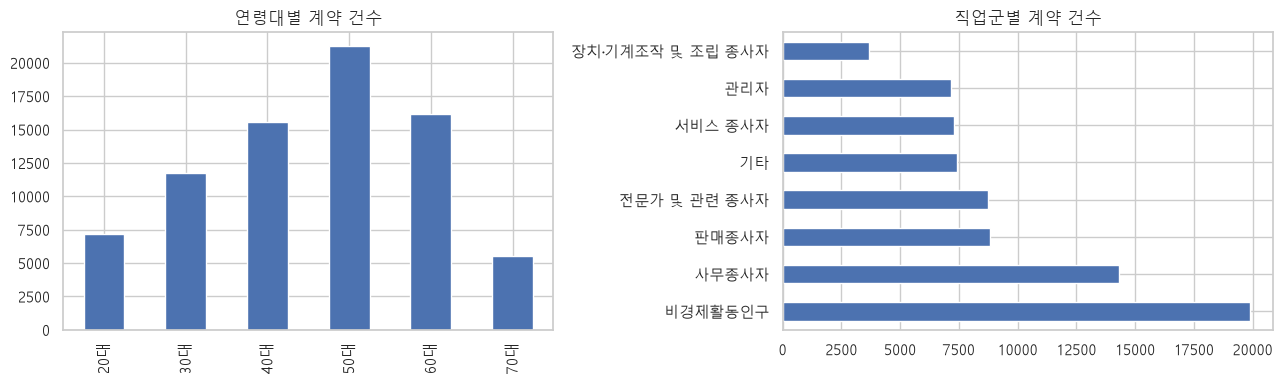

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ins["age"].value_counts().reindex(AGE_ORDER).plot(kind="bar", ax=ax[0], color="#4C72B0")
ax[0].set_title("연령대별 계약 건수"); ax[0].set_xlabel("")

ins["occupation_group"].value_counts().plot(kind="barh", ax=ax[1], color="#4C72B0")
ax[1].set_title("직업군별 계약 건수"); ax[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIG / "01_dist.png", dpi=150, bbox_inches="tight")
plt.show()

### 4-2. 연령과 직업군의 교차 분포

두 변수가 독립적인지 확인한다. 심하게 얽혀 있다면 단순 비교로는
어느 쪽 효과인지 구분할 수 없다.

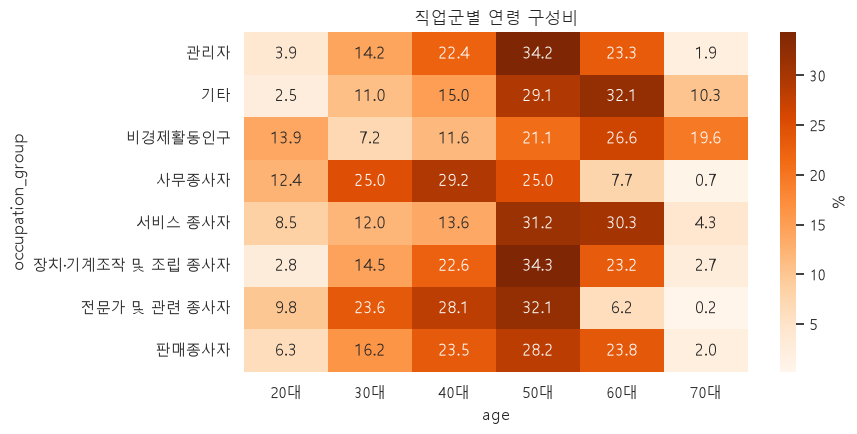

In [10]:
occ_age = pd.crosstab(ins["occupation_group"], ins["age"], normalize="index")[AGE_ORDER] * 100

plt.figure(figsize=(9, 4.5))
sns.heatmap(occ_age, annot=True, fmt=".1f", cmap="Oranges", cbar_kws={"label": "%"})
plt.title("직업군별 연령 구성비")
plt.tight_layout()
plt.savefig(FIG / "02_occ_age.png", dpi=150, bbox_inches="tight")
plt.show()

**발견**

사무종사자는 20~30대가 37.4%인 반면 60대 이상은 8.4%에 그친다.
장치·기계조작 종사자는 50대가 34.3%로 가장 많다.

즉 연령과 직업군은 강하게 얽혀 있어, "젊은 층이 저축성을 선호한다"는
관찰이 실제로는 "사무직이 저축성을 선호한다"일 가능성이 있다.
이 교란을 분리하는 것이 본 분석의 핵심 과제다.

## 5. 상품 카테고리 구성비

### 5-1. 연령대별

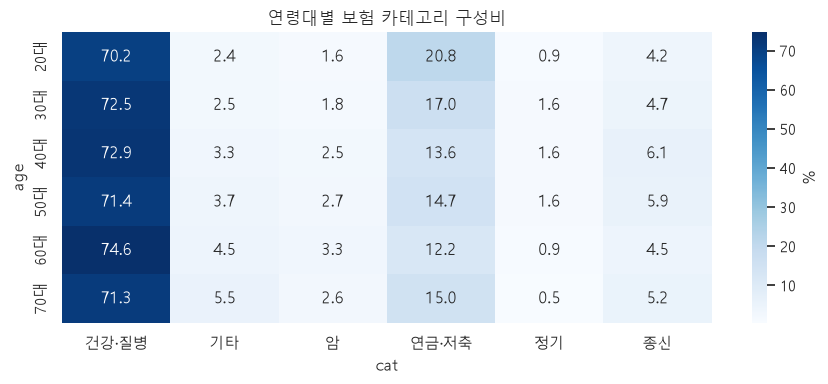

In [11]:
mix_age = pd.crosstab(ins["age"], ins["cat"], normalize="index").reindex(AGE_ORDER) * 100

plt.figure(figsize=(9, 4))
sns.heatmap(mix_age, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "%"})
plt.title("연령대별 보험 카테고리 구성비")
plt.tight_layout()
plt.savefig(FIG / "03_mix_age.png", dpi=150, bbox_inches="tight")
plt.show()

### 5-2. 직업군별

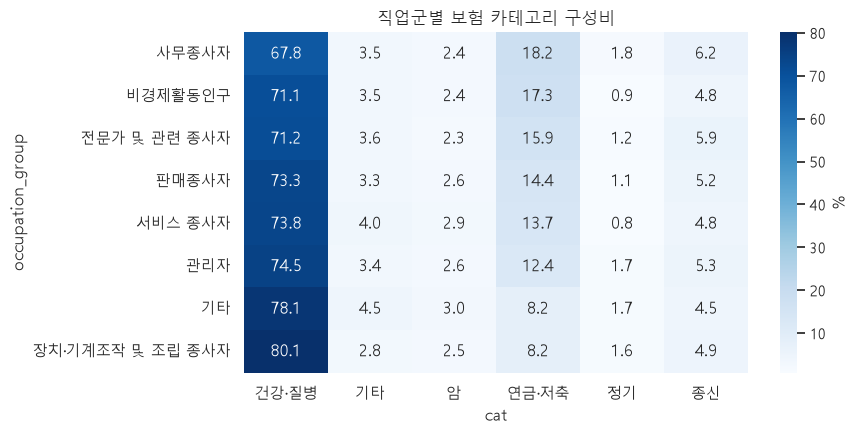

In [12]:
mix_occ = (pd.crosstab(ins["occupation_group"], ins["cat"], normalize="index") * 100
           ).sort_values("연금·저축", ascending=False)

plt.figure(figsize=(9, 4.5))
sns.heatmap(mix_occ, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "%"})
plt.title("직업군별 보험 카테고리 구성비")
plt.tight_layout()
plt.savefig(FIG / "04_mix_occ.png", dpi=150, bbox_inches="tight")
plt.show()

**발견**

연금·저축 비중이 연령대에서는 20.8%~12.2%(1.7배), 직업군에서는
18.2%~8.2%(2.2배) 범위로 나타나 직업군 간 편차가 더 크다.

건강·질병은 연령대별로 70~75%로 평탄하나, 직업군에서는
사무종사자 67.8% vs 장치·기계조작 80.1%로 12.3%p 벌어진다.

## 6. 교란 분리

연령과 직업군이 얽혀 있으므로, 한쪽을 고정한 상태에서
다른 쪽의 효과가 남는지 확인한다.

분석 대상: 연금·저축 가입 여부 (전체의 14.9%)

In [13]:
sav = ins.assign(s=(ins["cat"] == "연금·저축").astype(int))

# 연령 고정 → 직업군 간 격차
by_age = (sav.groupby(["age", "occupation_group"])["s"]
            .agg(["mean", "count"]).query("count >= 100"))
spread_age = (by_age.groupby("age")["mean"].agg(["max", "min"])
                .assign(격차=lambda d: (d["max"] - d["min"]) * 100)
                .reindex(AGE_ORDER))

# 직업군 고정 → 연령 간 격차
by_occ = (sav.groupby(["occupation_group", "age"])["s"]
            .agg(["mean", "count"]).query("count >= 100"))
spread_occ = (by_occ.groupby("occupation_group")["mean"].agg(["max", "min"])
                .assign(격차=lambda d: (d["max"] - d["min"]) * 100))

print("[연령 고정 시 직업군 간 격차]"); print(spread_age["격차"].round(1).to_string())
print(f"평균 {spread_age['격차'].mean():.1f}%p\n")
print("[직업군 고정 시 연령 간 격차]"); print(spread_occ["격차"].round(1).to_string())
print(f"평균 {spread_occ['격차'].mean():.1f}%p")

[연령 고정 시 직업군 간 격차]
age
20대    18.1
30대    16.0
40대     9.8
50대    10.6
60대     6.8
70대    11.7
평균 12.2%p

[직업군 고정 시 연령 간 격차]
occupation_group
관리자                  8.3
기타                   5.9
비경제활동인구              7.7
사무종사자               16.6
서비스 종사자              6.0
장치·기계조작 및 조립 종사자     0.6
전문가 및 관련 종사자         5.9
판매종사자                7.9
평균 7.4%p


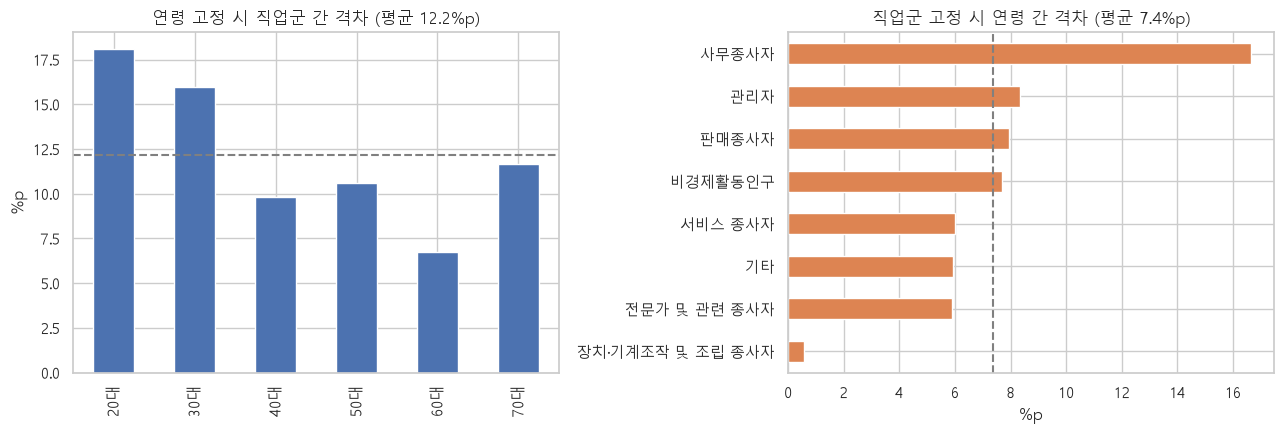

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

spread_age["격차"].plot(kind="bar", ax=ax[0], color="#4C72B0")
ax[0].axhline(spread_age["격차"].mean(), ls="--", c="gray")
ax[0].set_title(f"연령 고정 시 직업군 간 격차 (평균 {spread_age['격차'].mean():.1f}%p)")
ax[0].set_xlabel(""); ax[0].set_ylabel("%p")

spread_occ["격차"].sort_values().plot(kind="barh", ax=ax[1], color="#DD8452")
ax[1].axvline(spread_occ["격차"].mean(), ls="--", c="gray")
ax[1].set_title(f"직업군 고정 시 연령 간 격차 (평균 {spread_occ['격차'].mean():.1f}%p)")
ax[1].set_ylabel(""); ax[1].set_xlabel("%p")

plt.tight_layout()
plt.savefig(FIG / "05_spread.png", dpi=150, bbox_inches="tight")
plt.show()

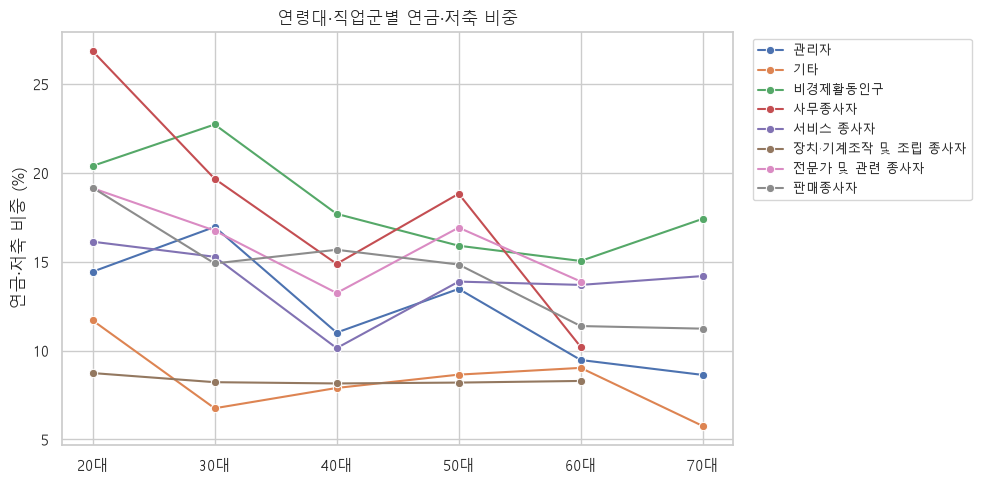

In [15]:
g = by_age.reset_index()
g["mean"] *= 100

plt.figure(figsize=(10, 5))
sns.lineplot(data=g, x="age", y="mean", hue="occupation_group", marker="o")
plt.title("연령대·직업군별 연금·저축 비중")
plt.ylabel("연금·저축 비중 (%)"); plt.xlabel("")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(FIG / "06_pension_by_age_occ.png", dpi=150, bbox_inches="tight")
plt.show()

**발견 1 — 직업군의 설명력이 더 크다**

연령을 고정해도 직업군 간 격차가 평균 12.2%p 남는 반면,
직업군을 고정하면 연령 간 격차는 평균 7.3%p로 줄어든다.

**발견 2 — 연령 효과는 직업군마다 다르다**

- 사무종사자: 16.6%p (20대 27.6% → 60대 9.8%)
- 장치·기계조작 종사자: 0.6%p (전 연령 8%대로 고정)

생산직에서는 연령이 사실상 무의미하고, 사무직에서는 결정적이다.
이는 두 변수 간 상호작용의 존재를 시사하며, 모델링 단계에서 검증한다.

**주의**

- 사무종사자 60대는 소득 3000만원 미만 비율이 26.6%로 50대(5.3%)의 5배.
  정년 후 집단 구성 변화 가능성이 있어 20~40대 중심으로 해석한다.
- 장치·기계조작 20대는 100건으로 표본이 적어 단정적 해석을 지양한다.
- 표본 100건 미만 조합은 그래프에서 제외했다.

In [17]:
ins.to_csv(ROOT / "data_processed.csv", index=False, encoding="utf-8-sig")
print("저장 완료:", len(ins), "건")

저장 완료: 77305 건


In [18]:
pip install pyarrow

   ---------------------------------------- 0.0/27.9 MB ? eta -:--:--
   - -------------------------------------- 0.8/27.9 MB 7.8 MB/s eta 0:00:04
   ------ --------------------------------- 4.2/27.9 MB 12.8 MB/s eta 0:00:02
   --------------- ------------------------ 10.5/27.9 MB 20.1 MB/s eta 0:00:01
   ------------------------------------ --- 25.4/27.9 MB 34.5 MB/s eta 0:00:01
   ---------------------------------------- 27.9/27.9 MB 32.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [19]:
ins = pd.read_csv(ROOT / "data_processed.csv", encoding="utf-8-sig")
ins["is_variable"] = ins["is_variable"].astype(bool)